# When one campaign-overlap model fails: an intuitive person-level market

This notebook asks one narrow question: **can a single cross-publisher overlap learned from canonical large Reach campaigns transfer to campaigns that select different people?**

It models people and publisher-local delivery—not account identifiers, RID-to-person mapping, Dirac mixtures, or a production VID system. Each row is one known synthetic person who can be reachable on either or both publishers. The two publishers never exchange delivery information and never take budget or impressions from one another.

The model deliberately uses fixed reach so the tests can hold campaign size constant and isolate audience composition. Opportunity and cost determine **which people fill each publisher's reach**, not how much reach the publisher receives. A separate budget-based implementation would answer a different question.

No overlap rate is assigned to a campaign. Overlap is measured only after each publisher independently selects its audience.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    repo = Path("/content/calibrated-vid")
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/world-federation-of-advertisers/calibrated-vid.git",
            str(repo),
        ], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(repo)], check=True)
    os.chdir(repo)

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

## The intuitive mechanism

The eligible market contains people with different publisher activity, placement use, time-of-day availability, response propensity, and opportunity cost.

For a person $i$ on publisher $p$, a Reach campaign ranks roughly by:

$$w_{ip}=\frac{\text{opportunity}_{ip}}{\text{cost}_{ip}}$$

A Traffic campaign also values publisher-local response:

$$w^{Traffic}_{ip}=\frac{\text{opportunity}_{ip}\times\text{response}_{ip}^{\alpha}}{\text{cost}_{ip}}$$

The ranking is not a literal auction or click probability. It is a compact representation of who is available and economical under a campaign's objective and settings. A random component prevents delivery from being perfectly deterministic.

Three observable mechanisms are isolated:

1. **Response contrast:** publishers may value different people under Traffic optimization.
2. **Activity depth:** a medium campaign takes the most available portion of a publisher's audience; a large campaign extends farther down that same ordering.
3. **Campaign profiles:** placement, flight length, and time window alter which people are locally available.

The sensitivity notebook turns each mechanism down to zero and increases it gradually.

### In plain language

Each publisher has its own ordering of people. Some people appear often and are inexpensive to reach; others appear less often or cost more. A Reach campaign generally fills its audience from the easiest opportunities first. A Traffic campaign changes that order by giving extra value to likely responders.

The publishers do not coordinate and one publisher does not take impressions from the other. We compare the two independently selected audiences only after delivery is complete.

In [2]:
import html
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import HTML, display

from calibrated_vid.intuitive_market import PROFILES, SEGMENTS, run_experiment

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
OUTPUT = ROOT / "outputs" / "behavioral_market"
campaigns, report = run_experiment(OUTPUT)
diagnostic = report["diagnostics"]

def show_table(rows, columns, digits=2):
    head = "".join(f"<th>{html.escape(label)}</th>" for _, label in columns)
    body = []
    for row in rows:
        cells = []
        for key, _ in columns:
            value = row[key]
            if isinstance(value, float):
                value = f"{value:.{digits}f}"
            cells.append(f"<td>{html.escape(str(value))}</td>")
        body.append("<tr>" + "".join(cells) + "</tr>")
    display(HTML("<table><thead><tr>" + head + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

diagnostic

{'baseline_overlap_percent': 32.72951388888889,
 'objective': {'pairs': 32,
  'traffic_lower_share': 1.0,
  'traffic_minus_reach_median_points': -13.218055555555559,
  'p10_points': -16.636388888888888,
  'p90_points': -0.8797222222222255},
 'direction': {'pairs': 24,
  'medium_large_higher_share': 1.0,
  'medium_large_minus_large_medium_median_points': 14.666666666666664,
  'p10_points': 14.342592592592595,
  'p90_points': 15.187037037037035},
 'large_profiles': {'campaigns': 70,
  'p10_overlap_percent': 17.589722222222225,
  'median_overlap_percent': 28.061111111111114,
  'p90_overlap_percent': 40.170833333333334,
  'p10_p90_width_points': 22.58111111111111,
  'profiles': [{'profile': 'broad_long',
    'label': 'Long flight, broad placements',
    'campaigns': 10,
    'median_overlap_percent': 32.795833333333334,
    'p10_overlap_percent': 32.62,
    'p90_overlap_percent': 32.94444444444444},
   {'profile': 'feed_short',
    'label': 'Short flight, feed-heavy',
    'campaigns': 10,
 

## People and campaign profiles

The archetypes are explanatory summaries, not advertiser targeting labels. Importantly, they are stable across every campaign. Campaigns cannot choose an archetype directly.

- **Dual regulars** are frequently available on both publishers.
- **Publisher-heavy regulars** are much more available on one publisher.
- **Publisher-specific responders** are valued differently by Traffic delivery.
- **Feed, video, daytime, evening, and occasional users** become more or less available under named campaign profiles.

The newer model has no independent campaign-by-archetype opportunity shocks. Variation comes from campaign settings that can be named and inspected.

In [3]:
segment_rows = [{
    "segment": row.name,
    "population %": 100 * row.share,
    "activity A": 0.5 * (row.feed_a + row.video_a),
    "activity B": 0.5 * (row.feed_b + row.video_b),
    "click A": row.click_a,
    "click B": row.click_b,
} for row in SEGMENTS]
show_table(segment_rows, [
    ("segment", "Synthetic person type"),
    ("population %", "Population %"),
    ("activity A", "Activity A"),
    ("activity B", "Activity B"),
    ("click A", "Response A"),
    ("click B", "Response B"),
])

profile_rows = [{
    "profile": row.label,
    "days": row.active_days,
    "video A": 100 * row.video_share_a,
    "video B": 100 * row.video_share_b,
    "schedule": row.schedule,
} for row in PROFILES]
show_table(profile_rows, [
    ("profile", "Campaign profile"),
    ("days", "Active days"),
    ("video A", "Video share A %"),
    ("video B", "Video share B %"),
    ("schedule", "Time window"),
])

Synthetic person type,Population %,Activity A,Activity B,Response A,Response B
dual_daily,24.00,0.79,0.73,0.03,0.03
a_regular_dual_occasional,17.00,0.86,0.39,0.02,0.01
b_heavy_regular,23.00,0.12,0.92,0.01,0.02
dual_video_regular,10.00,0.67,0.65,0.04,0.04
a_response_regular,9.00,0.74,0.31,0.36,0.01
b_response_regular,9.00,0.28,0.78,0.01,0.36
daytime_dual,4.00,0.47,0.46,0.04,0.04
evening_video_dual,2.00,0.52,0.51,0.06,0.06
occasional_dual,2.00,0.20,0.19,0.02,0.02


Campaign profile,Active days,Video share A %,Video share B %,Time window
"Long flight, broad placements",42,35.00,35.00,broad
"Short flight, feed-heavy",10,5.00,5.00,broad
"Short flight, video-heavy",10,90.00,90.00,broad
"A feed-heavy, B video-heavy",18,8.00,88.00,broad
"A video-heavy, B feed-heavy",18,88.00,8.00,broad
"Daytime, feed-heavy",18,10.00,10.00,daytime
"Evening, video-heavy",18,82.00,82.00,evening


## Test 1: Traffic and Reach select different people

Every point is a matched pair. Reach and Traffic use the same population, reach totals, placements, flight, time window, costs, and random delivery draw. Only the objective changes.

Traffic values publisher-specific responders. When the strongest responders differ across publishers, the two Traffic audiences intersect less than the matched Reach audiences.

### What is happening and why

Reach is content to serve an inexpensive available person even if that person rarely clicks. Traffic is willing to prioritize a more expensive person when that person is much more likely to respond. If Publisher A's likely responders are different people from Publisher B's likely responders, the two Traffic audiences separate and their overlap falls.

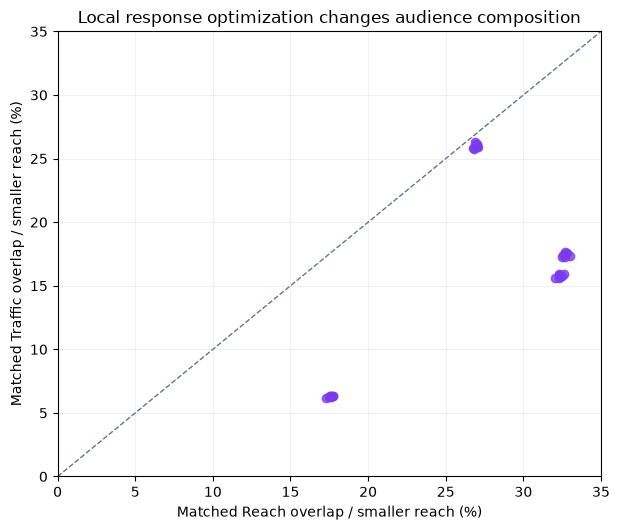

Matched pairs,Traffic-lower share,Median Traffic − Reach points,P10 difference,P90 difference
32,1.00,-13.22,-16.64,-0.88


In [4]:
evaluation = [row for row in campaigns if row.split == "evaluation"]
by_pair = {}
for row in evaluation:
    by_pair.setdefault(row.comparison_id, {})[row.scenario] = row
objective_pairs = [
    (rows["objective_reach"], rows["objective_traffic"])
    for rows in by_pair.values()
    if {"objective_reach", "objective_traffic"}.issubset(rows)
]
reach = 100 * np.asarray([left.overlap_rate for left, _ in objective_pairs])
traffic = 100 * np.asarray([right.overlap_rate for _, right in objective_pairs])
fig, ax = plt.subplots(figsize=(6.3, 5.4))
ax.scatter(reach, traffic, color="#7c3aed", alpha=0.78)
limit = max(reach.max(), traffic.max()) + 2
ax.plot([0, limit], [0, limit], "--", color="#64748b", linewidth=1)
ax.set(xlabel="Matched Reach overlap / smaller reach (%)", ylabel="Matched Traffic overlap / smaller reach (%)", title="Local response optimization changes audience composition", xlim=(0, limit), ylim=(0, limit))
ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(OUTPUT / "objective_pairing.png", dpi=180)
plt.show()
show_table([diagnostic["objective"]], [
    ("pairs", "Matched pairs"),
    ("traffic_lower_share", "Traffic-lower share"),
    ("traffic_minus_reach_median_points", "Median Traffic − Reach points"),
    ("p10_points", "P10 difference"),
    ("p90_points", "P90 difference"),
])

> **Test 1 conclusion.** A large-Reach average does not transfer when objective-specific delivery values different people on the two publishers. The effect disappears or reverses when publisher response rankings are made similar; the sensitivity notebook shows that boundary explicitly.

## Test 2: size direction changes how deeply each publisher reaches

The paired campaigns use the same Reach objective, target, long broad-placement profile, cost structure, and random draw. The medium and large reaches are simply reversed.

The medium audience is nested inside the large audience for each publisher. Publisher A's most available users contain more dual-publisher regulars, while Publisher B's most available users contain more B-heavy regulars. A large campaign expands farther into each publisher's activity ordering. The resulting intersection therefore depends on which publisher supplies the medium audience.

### What is happening and why

A medium campaign stops after reaching a relatively small group of easy-to-reach people. A large campaign keeps going into less-active or more-expensive people. If the easiest people on Publisher A use both publishers while the easiest people on Publisher B are more B-specific, swapping which publisher is medium changes the shared audience—even though the same two reach totals are used.

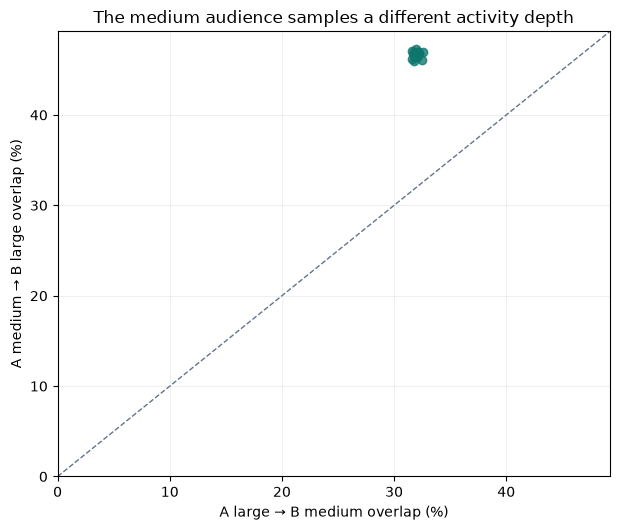

Matched pairs,Medium→large higher share,Median direction gap points,P10 gap,P90 gap
24,1.00,14.67,14.34,15.19


In [5]:
direction_pairs = [
    (rows["direction_medium_large"], rows["direction_large_medium"])
    for rows in by_pair.values()
    if {"direction_medium_large", "direction_large_medium"}.issubset(rows)
]
medium_large = 100 * np.asarray([left.overlap_rate for left, _ in direction_pairs])
large_medium = 100 * np.asarray([right.overlap_rate for _, right in direction_pairs])
fig, ax = plt.subplots(figsize=(6.3, 5.4))
ax.scatter(large_medium, medium_large, color="#0f766e", alpha=0.78)
limit = max(medium_large.max(), large_medium.max()) + 2
ax.plot([0, limit], [0, limit], "--", color="#64748b", linewidth=1)
ax.set(xlabel="A large → B medium overlap (%)", ylabel="A medium → B large overlap (%)", title="The medium audience samples a different activity depth", xlim=(0, limit), ylim=(0, limit))
ax.grid(alpha=0.18)
fig.tight_layout()
fig.savefig(OUTPUT / "direction_pairing.png", dpi=180)
plt.show()
show_table([diagnostic["direction"]], [
    ("pairs", "Matched pairs"),
    ("medium_large_higher_share", "Medium→large higher share"),
    ("medium_large_minus_large_medium_median_points", "Median direction gap points"),
    ("p10_points", "P10 gap"),
    ("p90_points", "P90 gap"),
])

> **Test 2 conclusion.** A large-to-large average cannot automatically represent both asymmetric size directions. The result requires publisher activity rankings to differ and delivery to meaningfully prefer the most available users. When either condition is removed, the directional gap collapses.

## Test 3: equal-size large Reach campaigns can encounter different active populations

Every campaign below has identical large Reach totals on both publishers and uses the Reach objective. Only named campaign conditions change.

Within a profile, repeated campaigns have very similar overlap. Most dispersion occurs **between explainable profiles**—for example, broad long-running delivery versus opposite placement mixes—not because the simulator draws arbitrary archetype shocks for every campaign.

### What is happening and why

Two campaigns can each reach 36,000 people without reaching the same 36,000 people. A short feed-heavy campaign mostly sees frequent feed users. A video-heavy or daytime campaign sees a different available population. The total reach is held constant so the chart isolates this change in composition.

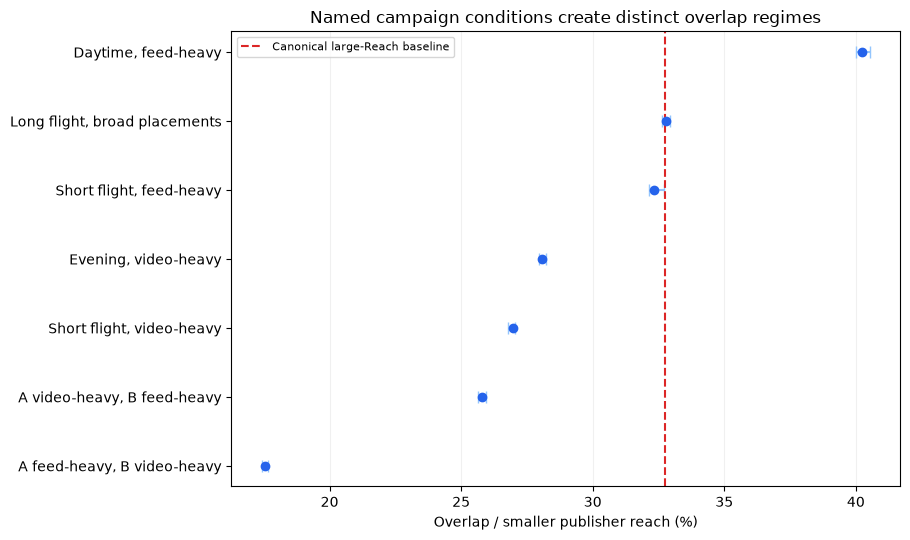

Campaigns,P10 overlap %,Median overlap %,P90 overlap %,P10–P90 width points
70,17.59,28.06,40.17,22.58


In [6]:
profiles = sorted(diagnostic["large_profiles"]["profiles"], key=lambda row: row["median_overlap_percent"])
fig, ax = plt.subplots(figsize=(9.2, 5.5))
y = np.arange(len(profiles))
med = np.asarray([row["median_overlap_percent"] for row in profiles])
low = med - np.asarray([row["p10_overlap_percent"] for row in profiles])
high = np.asarray([row["p90_overlap_percent"] for row in profiles]) - med
ax.errorbar(med, y, xerr=[low, high], fmt="o", color="#2563eb", ecolor="#93c5fd", capsize=4)
ax.axvline(diagnostic["baseline_overlap_percent"], color="#dc2626", linestyle="--", label="Canonical large-Reach baseline")
ax.set(xlabel="Overlap / smaller publisher reach (%)", ylabel="", yticks=y, yticklabels=[row["label"] for row in profiles], title="Named campaign conditions create distinct overlap regimes")
ax.grid(axis="x", alpha=0.18)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / "profile_overlap.png", dpi=180)
plt.show()
show_table([diagnostic["large_profiles"]], [
    ("campaigns", "Campaigns"),
    ("p10_overlap_percent", "P10 overlap %"),
    ("median_overlap_percent", "Median overlap %"),
    ("p90_overlap_percent", "P90 overlap %"),
    ("p10_p90_width_points", "P10–P90 width points"),
])

> **Test 3 conclusion.** One large-Reach average represents the canonical profile but misses other large campaigns whose placement, flight, or availability window reaches a different portion of the same eligible market. When all profiles are made identical, the P10–P90 width collapses to sampling noise.

## What a single unconditional model misses

The fitted baseline is the mean overlap of canonical long, broad-placement, large Reach training campaigns. It is deliberately just one number. The chart compares it with the evaluation regimes generated above.

This does not prove that no single statistical model can work. It shows that **one unconditional overlap parameter** cannot work across heterogeneous campaign conditions. A richer single model could use objective, publisher-size direction, placements, flight, and realized delivery signals—but it would need representative training data spanning those conditions.

### Why this matters

An average learned from one familiar campaign type can be correct for that type and still be wrong elsewhere. When the predicted overlap is too high, the model understates how many additional people the second publisher contributes. When it is too low, it overstates that contribution.

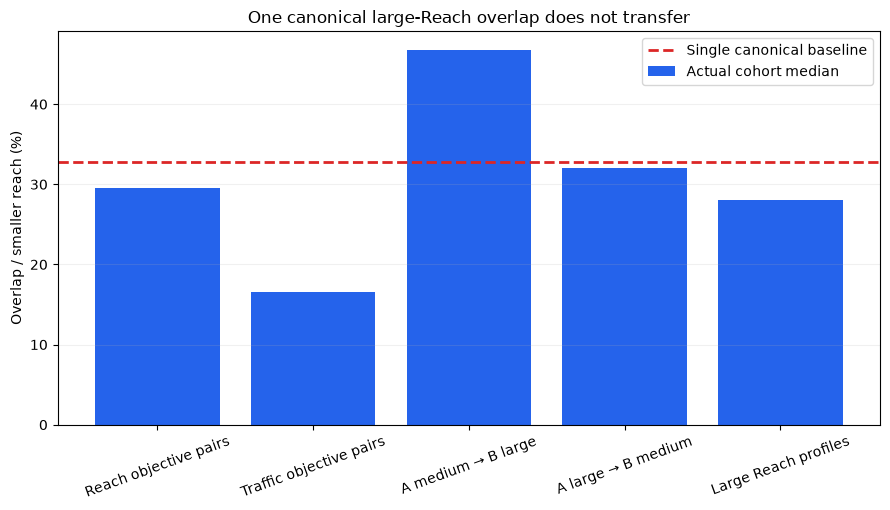

Evaluation MAE points,Evaluation P90 error points
7.99,15.45


In [7]:
scenario_groups = {
    "Reach objective pairs": [row for row in evaluation if row.scenario == "objective_reach"],
    "Traffic objective pairs": [row for row in evaluation if row.scenario == "objective_traffic"],
    "A medium → B large": [row for row in evaluation if row.scenario == "direction_medium_large"],
    "A large → B medium": [row for row in evaluation if row.scenario == "direction_large_medium"],
    "Large Reach profiles": [row for row in evaluation if row.scenario == "large_reach_profiles"],
}
labels = list(scenario_groups)
medians = [100 * np.median([row.overlap_rate for row in scenario_groups[label]]) for label in labels]
baseline = diagnostic["baseline_overlap_percent"]
fig, ax = plt.subplots(figsize=(9.0, 5.2))
x = np.arange(len(labels))
ax.bar(x, medians, color="#2563eb", label="Actual cohort median")
ax.axhline(baseline, color="#dc2626", linestyle="--", linewidth=2, label="Single canonical baseline")
ax.set(ylabel="Overlap / smaller reach (%)", title="One canonical large-Reach overlap does not transfer", xticks=x, xticklabels=labels)
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", alpha=0.18)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / "global_baseline.png", dpi=180)
plt.show()
show_table([diagnostic["global_model"]], [
    ("evaluation_mae_points", "Evaluation MAE points"),
    ("evaluation_p90_error_points", "Evaluation P90 error points"),
])

## Scope and remaining shortcut

This version improves interpretability, not realism in every dimension.

- It starts from known people and does not model accounts or VID assignment.
- It fixes publisher reach and studies audience composition at that size.
- Its activity and response patterns are synthetic and not estimates of any publisher.
- Its campaign profiles are stylized summaries of real settings.
- Campaign-profile strength is restricted to 0–1.25 so every interpolated flight remains positive.

Those choices make the causal comparisons readable. The companion sensitivity notebook tests whether the results require narrow parameter values. Its main standard is not that every random configuration reproduces all three discrepancies; null mechanisms should produce null effects. The standard is that each discrepancy grows smoothly when its stated mechanism is strengthened and disappears when that mechanism is removed.